In [33]:
import numpy as np
import xarray as xr
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [13]:
ds = xr.open_dataset('../../../Med_Global_EKE/data/eur_L3_008_061/vDT2021/processed/dt_europe_s6a_lr_phy_l3_2022_2023.nc')

In [15]:
ds = ds.rename({
    'latitude': 'lat',
    'longitude': 'lon'})
ds['lon'] = xr.where(ds['lon'] > 180, ds['lon'] - 360, ds['lon'])

In [17]:
ds = xr.open_dataset('../../data/dt_europe_s3a_phy_l3_1hz_20210402_20240205.nc')

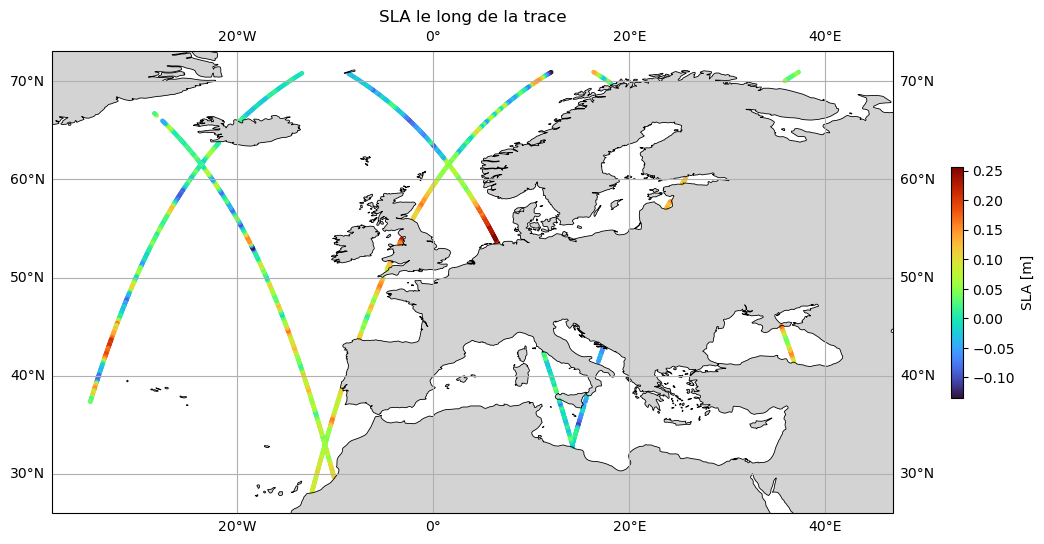

In [20]:
# Sélectionner la variable SLA (par ex. sla_filtered)
sla = ds.sla_filtered

lon = ds.longitude
lat = ds.latitude

fig = plt.figure(figsize=(15, 6))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Fond de carte
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(draw_labels=True)

# Scatter le long de la trace
im = ax.scatter(
    lon, lat, c=sla,
    cmap='turbo', s=5,
    transform=ccrs.PlateCarree()
)

plt.colorbar(im, ax=ax, label='SLA [m]', shrink=0.5)
ax.set_title("SLA le long de la trace")

plt.show()

In [22]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371000.0  # m
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R * c

In [23]:
i = 100  # exemple
d = haversine(ds.longitude[i], ds.latitude[i],
              ds.longitude[i+1], ds.latitude[i+1])

print("Distance (m) :", d)


Distance (m) : <xarray.DataArray ()> Size: 8B
np.float64(6706.88710420319)


In [62]:
ds = xr.open_dataset('../../../Med_Global_EKE/data/glo_allsat_L4_008_047/vDT2021/2022/dt_global_allsat_phy_l4_2022.nc')
ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})


In [71]:
ds = ds.sel(
    lat=slice(40, 50),
    lon=slice(-30, 20)
)

In [72]:
R = 6371000

lat = np.deg2rad(ds.lat)

dx = R * np.cos(lat) * np.deg2rad(ds.lon.diff("lon").mean())
dy = R * np.deg2rad(ds.lat.diff("lat").mean())

In [73]:
def gaussian_filter_nan(da, sigma):

    data = da.values

    mask = np.isfinite(data).astype(float)

    data_filled = np.nan_to_num(data, nan=0.0)

    # convolution du champ
    filtered_data = ndi.gaussian_filter(data_filled, sigma=(0,sigma,sigma))

    # convolution du masque
    filtered_mask = ndi.gaussian_filter(mask, sigma=(0,sigma,sigma))

    # normalisation
    with np.errstate(invalid="ignore"):
        result = filtered_data / filtered_mask

    result[filtered_mask < 1e-6] = np.nan

    return xr.DataArray(result, coords=da.coords, dims=da.dims)

def compute_gradients(u, v, dx, dy):

    dudx = u.differentiate("lon") / dx
    dudy = u.differentiate("lat") / dy

    dvdx = v.differentiate("lon") / dx
    dvdy = v.differentiate("lat") / dy

    return dudx, dudy, dvdx, dvdy

def compute_energy_flux(ds, sigma, dx, dy):

    u = ds["ugos"]
    v = ds["vgos"]

    # filtrage
    u_bar = gaussian_filter_nan(u, sigma)
    v_bar = gaussian_filter_nan(v, sigma)

    # produits
    uu_bar = gaussian_filter_nan(u*u, sigma)
    uv_bar = gaussian_filter_nan(u*v, sigma)
    vv_bar = gaussian_filter_nan(v*v, sigma)

    # tenseur subfilter
    tau_xx = uu_bar - u_bar*u_bar
    tau_xy = uv_bar - u_bar*v_bar
    tau_yy = vv_bar - v_bar*v_bar

    # gradients
    dudx, dudy, dvdx, dvdy = compute_gradients(u_bar, v_bar, dx, dy)

    # flux énergie
    Pi = -(tau_xx*dudx +
           tau_xy*dudy +
           tau_xy*dvdx +
           tau_yy*dvdy)

    Pi.name = "energy_flux"

    return Pi

In [80]:
Pi = compute_energy_flux(ds, sigma=2, dx=dx, dy=dy)

In [81]:
Pi_mean = Pi.mean("time")

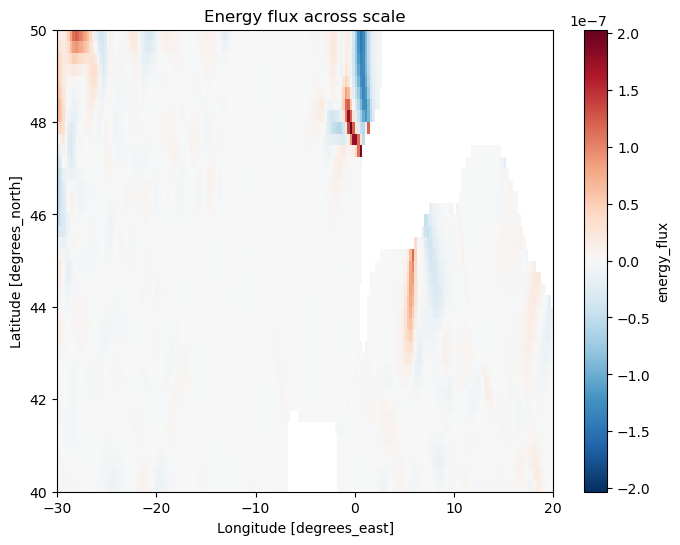

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

Pi_mean.plot(
    cmap="RdBu_r",
    vmin=-np.nanmax(abs(Pi_mean)),
    vmax=np.nanmax(abs(Pi_mean))
)

plt.title("Energy flux across scale")
plt.show()